## Healthcare Fraud Detection Using Machine Learning

Healthcare fraud poses a signifigant risk, with estimated financial losses of as much as 15%[<sup>1</sup>](https://google.com). With Canadian healthcare cost projected to be almost 400 billion dollars annually[<sup>2</sup>](https://www.cihi.ca/en/national-health-expenditure-trends/nhex-trends-reports/nhex-trends-2025-snapshot) this could mean as much as a 60 billion dollar loss in 2025 alone.

In attempts to better classify healthcare fraud I have trained a model using machine learning to detect fraudulent cases. We will be using a data set obtained from Kaggle called *Healthcare Fraud Detection Dataset*[<sup>3</sup>](https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset).

We will be using Panda's to convert our dataset into a frame, and use scikit-learn to train a model. Then we will try some additional tuning to improve model evaluations. Last we will analyze the data and see if we can learn anything about creating better healthcare fraud detection in the future. 

### Set Up

First let's import our dependancies and load the data into a frame using Pandas.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./healthcare_fraud_detection.csv")

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

### Features and Targets 
Now that we have our data, let's create our features, X, and our target, y. Provider_ID and Claim_ID are not relevant and could skew results, so they will be dropped from our features. We will also drop Is_Fraud as that will be used as our target. 

In [2]:
X = df.drop(columns=["Is_Fraud", "Provider_ID", "Claim_ID"])
y = df["Is_Fraud"]

### Cleaning
We can deal with missing data using using fillna and encode the text using get_dummies.

In [3]:
X["Insurance_Type"] = X["Insurance_Type"].fillna("Unknown")
X["Provider_Specialty"] = X["Provider_Specialty"].fillna("Unknown")
X["Prior_Visits_12m"] = X["Prior_Visits_12m"].fillna(0)

X = pd.get_dummies(X, drop_first=True)

### Training
Now that our data is ready we can start training the model.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Evaluation
Let's take a look at our results.

In [5]:
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.963
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1847
           1       0.98      0.53      0.69       153

    accuracy                           0.96      2000
   macro avg       0.97      0.76      0.83      2000
weighted avg       0.96      0.96      0.96      2000



#### Tuning
Results are not too great, recall is at 53%. Let's see if we can improve those results. Let's try making the model more sensitive and flag anything above a 40% confidence rating.

In [6]:
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > 0.4).astype(int)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.9705
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1847
           1       0.93      0.67      0.78       153

    accuracy                           0.97      2000
   macro avg       0.95      0.83      0.88      2000
weighted avg       0.97      0.97      0.97      2000



Recall jumped to 67%. It looks like there is potential for finer tuning here. Let's try running a quick loop to find the optimal classification threshold.

In [7]:
from sklearn.metrics import f1_score

best_t = 0
best_score = 0

for t in [i/100 for i in range(10, 90)]:
    preds = (probs > t).astype(int)
    score = f1_score(y_test, preds)

    if score > best_score:
        best_score = score
        best_t = t

print("Best threshold:", best_t)

Best threshold: 0.29


### Reevaluation
Let's try evaluating the model again using our best threshold.

In [8]:
probs = model.predict_proba(X_test)[:, 1]
preds = (probs > best_t).astype(int)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.972
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1847
           1       0.81      0.83      0.82       153

    accuracy                           0.97      2000
   macro avg       0.90      0.91      0.90      2000
weighted avg       0.97      0.97      0.97      2000



We can note that recall has improved 30% with this adjustment. There is a tradeoff here however, as precision has dropped from 93% to 81%. This suggests our model is now hitting a higher number of false positives (93% to 81%). In the case of healthcare fraud, the 12% increase in false positive rate is more than acceptable for a 30% increase in detection rates. False positives flagged by the model can be weeded out in the review process. 

### Features
Let's look at which features were most important to our model in making its determination.

In [9]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

Days_Between_Service_and_Claim           0.243330
Claim_Amount                             0.099722
Approved_Amount                          0.070125
Number_of_Claims_Per_Provider_Monthly    0.045083
Claim_Status_Rejected                    0.039321
Claim_Status_Pending                     0.029277
Patient_Age                              0.028903
Prior_Visits_12m                         0.020479
Procedure_Code                           0.019170
Length_of_Stay                           0.017786
dtype: float64


The most important feature is Days_Between_Service_and_Claim, with almost a quarter relevance.  Let's start by getting the averages between fraudlent and non-fraudlent claims.

In [10]:
df.groupby("Is_Fraud")["Days_Between_Service_and_Claim"].mean()

Is_Fraud
0    15.447825
1     2.974668
Name: Days_Between_Service_and_Claim, dtype: float64

We can immediately see a huge disparity in average time between service and claim for legitimate and fraudulent claims. Legitimate claims average 15 days, whereas fraudlent claims average less than 3. Let's graph this out.

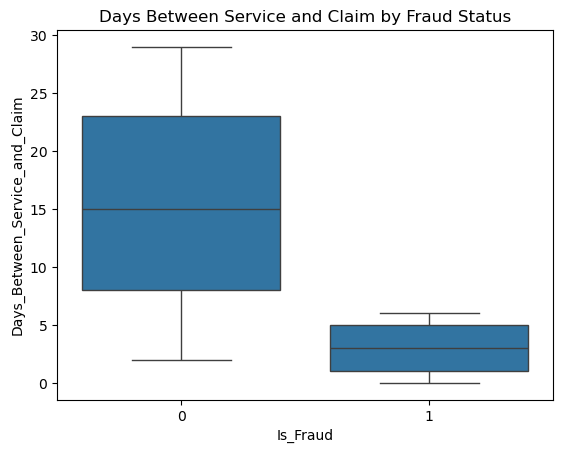

In [11]:
sns.boxplot(
    x="Is_Fraud",
    y="Days_Between_Service_and_Claim",
    data=df
)

plt.title("Days Between Service and Claim by Fraud Status")
plt.show()

We can see that fraudlent claims were all resolved within a week. Although some legitimate claims were resolved within a week, no fraudulent claims were resolved outside a week. This suggests targeting claims with days between service and claim of one week or less would have caught all of the fraudlent cases in this dataset. Let's explore this heuristic further. To start, we will calculate how many legitimate cases had a service to claim period of one week or less.

In [16]:
total_legit = df[df["Is_Fraud"] == 0].shape[0]

flagged_legit = df[
    (df["Is_Fraud"] == 0) &
    (df["Days_Between_Service_and_Claim"] <= 7)
].shape[0]

percent_flagged_legit = (flagged_legit / total_legit) * 100

print("Legit claims flagged:", flagged_legit)
print("Total legit claims:", total_legit)
print("Percent of legit claims flagged by heuristic:", percent_flagged_legit)

Legit claims flagged: 1998
Total legit claims: 9171
Percent of legit claims flagged by heuristic: 21.786064769381746


We can now break down what the accuracy and precision of a heuristic like this would be.

In [13]:
total_predictions = df[
    (df["Days_Between_Service_and_Claim"] <= 7)
].shape[0]

true_positives = df[
    (df["Is_Fraud"] == 1) &
    (df["Days_Between_Service_and_Claim"] <= 7)
].shape[0]

true_negatives = df[
    (df["Is_Fraud"] == 0) &
    (df["Days_Between_Service_and_Claim"] > 7)
].shape[0]

total_fraud = df[
    (df["Is_Fraud"] == 1)
].shape[0]

false_positives = total_predictions - true_positives
false_negatives = total_fraud - true_positives
accuracy = (true_positives + true_negatives) / (true_positives + true_negatives + false_positives + false_negatives)
precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)
f1 = 2 * (precision * recall / (precision + recall))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall", recall)
print("F1", f1)

Accuracy: 0.8002
Precision: 0.29324372125928544
Recall 1.0
F1 0.45350109409190364


This heuristic would catch all cases of fraud in the dataset but at a large cost to precision. Because there is a higher amount of legitimate cases than fraudulent ones, it results in a signifigant number of false positives. Due to this the F1 score drops well below the performance of our model (45% to 82%).

The second and third most important features in our model are Claim_Amount and Approved_Amount. Let's see if there are any insights we can gain from checking these averages.

In [14]:
df.groupby("Is_Fraud")["Claim_Amount"].mean()


Is_Fraud
0    535.008352
1    990.931797
Name: Claim_Amount, dtype: float64

In [15]:
df.groupby("Is_Fraud")["Approved_Amount"].mean()

Is_Fraud
0    469.154258
1    545.871978
Name: Approved_Amount, dtype: float64

Another major anomoly appears in the average claim amounts. Fraudulent claims average almost twice what legitimate claims do, a signifigant divergence. The divergence in approved amounts exists, suggesting larger approvals also share some correlation with fraud, however this deviation is smaller, perhaps due to adjustments before approval on large claim amounts.

### Conclusion

| Approach        | Recall (Fraud) | Precision | Legit Flag Rate |
|----------------|---------------|----------|-----------------|
| Heuristic (≤7d)| 100%          | 29%      | 21.8%           |
| ML Model       | 83%           | 81%      | ~3–5% (implied) |

By lowering the classification threshold from the default 0.5 to 0.29 we can significantly improve recall of our model (53% to 83%). This results in a reduction of precision (93% to 81%). We assume that the 12% increase in false positives is worth the 30% increase in recall as false positives will be caught in the claims review process.

The model identifies the most important feature as time between service and claim. Legitimate claims average more than two weeks between service and claim, while fraudlent claims tend to have a period shorter than 3 days. We can use this insight to draw some heuristics. Implementing an automatic review of claims whose period was less than one week would have flagged 100% of fraudlent claims. However due to a large increase in false positives, the impact on review workloads must be strongly considered, as 21% of all legimate claims would be flagged. 

Other important features are claim amounts and adjusted amounts. Fraudulent claim amounts average almost double what legitimate claims do (535 to 990). Approved amounts share this pattern, albiet weaker (469 to 545). The possibility of claims adjustment before approval likely normalizes claim amounts and weakens its potential as a heuristic.

For fraud detection moving forward, claims with a waiting period of less than a week for service should trigger automatic review. Claims with abnormally high claim amounts should also warrant additional review. 

